In [1]:
import kagglehub

In [2]:
sales_path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

print("Sales Dataset Path:", sales_path)

Sales Dataset Path: C:\Users\CH Sridevi\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2


In [3]:
vg_path = kagglehub.dataset_download("gregorut/videogamesales")

print("Video Game Dataset Path:", vg_path)

Video Game Dataset Path: C:\Users\CH Sridevi\.cache\kagglehub\datasets\gregorut\videogamesales\versions\2


In [4]:
import pandas as pd
import os

sales_df = pd.read_csv(os.path.join(sales_path, "train.csv"))
vg_df = pd.read_csv(os.path.join(vg_path, "vgsales.csv"))

In [5]:
print(sales_df.head())
print(vg_df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import os
warnings.filterwarnings('ignore')

# 1. Load the primary dataset using kagglehub
print("Downloading Superstore dataset...")
superstore_path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
df = pd.read_csv(os.path.join(superstore_path, 'train.csv'))

# ... (continue with the rest of your Task 1 code)

In [7]:
!pip install prophet xgboost

1. Highest Revenue Category: Technology
2. Consistent Growth Region: West
3. Avg Time to Ship (Days): 3.9611224489795918
Merged Supplementary Data Sample:
    Year        Sales  Global_Sales
0  2015  479856.2081        264.44
1  2016  459436.0054         70.93
2  2017  600192.5500          0.05


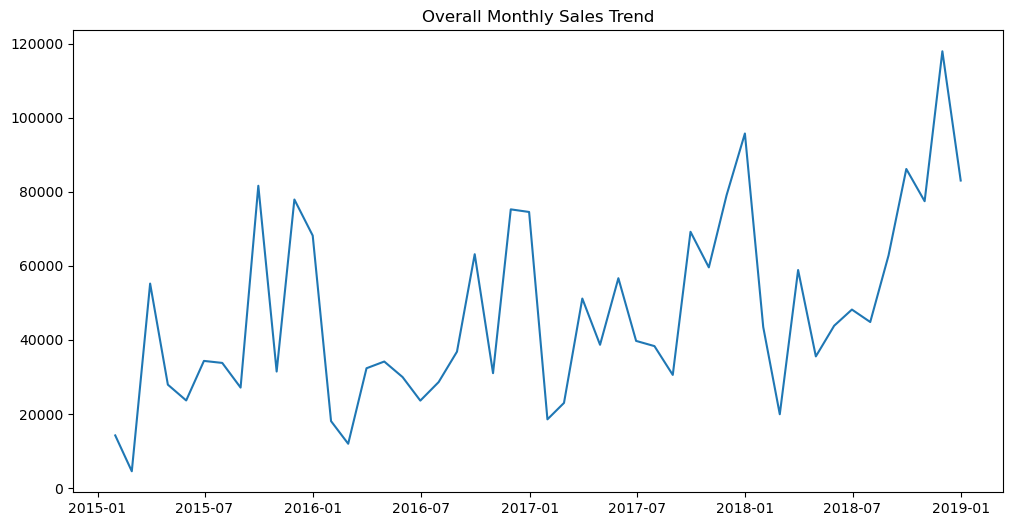

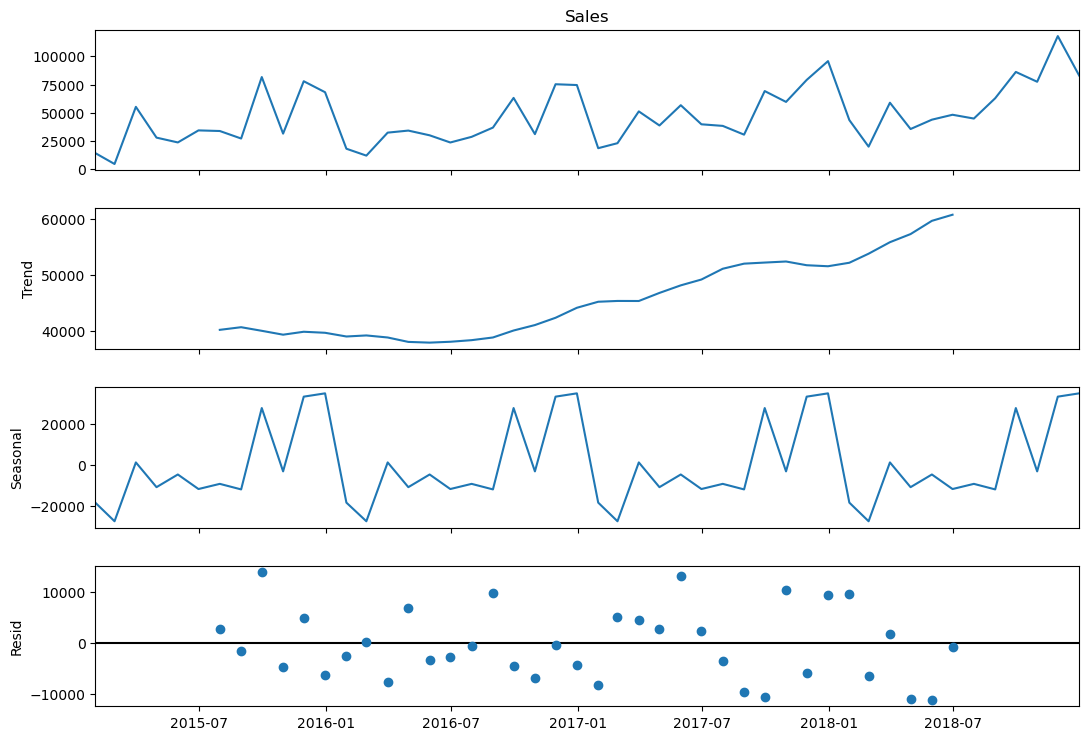

ADF Statistic: -4.416136761430768, p-value: 0.00027791039276670677


16:06:40 - cmdstanpy - INFO - Chain [1] start processing
16:06:40 - cmdstanpy - INFO - Chain [1] done processing


Forecasts completed! Compile the metrics into the required table.


16:06:41 - cmdstanpy - INFO - Chain [1] start processing
16:06:42 - cmdstanpy - INFO - Chain [1] done processing
16:06:42 - cmdstanpy - INFO - Chain [1] start processing
16:06:43 - cmdstanpy - INFO - Chain [1] done processing
16:06:43 - cmdstanpy - INFO - Chain [1] start processing
16:06:43 - cmdstanpy - INFO - Chain [1] done processing
16:06:44 - cmdstanpy - INFO - Chain [1] start processing
16:06:44 - cmdstanpy - INFO - Chain [1] done processing
16:06:45 - cmdstanpy - INFO - Chain [1] start processing
16:06:45 - cmdstanpy - INFO - Chain [1] done processing


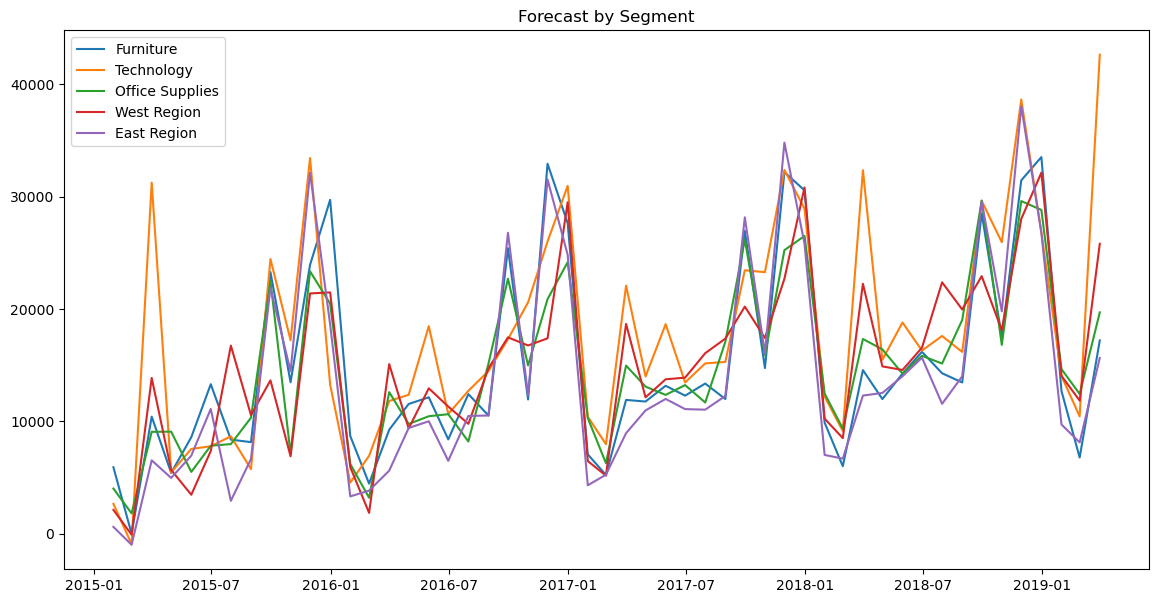

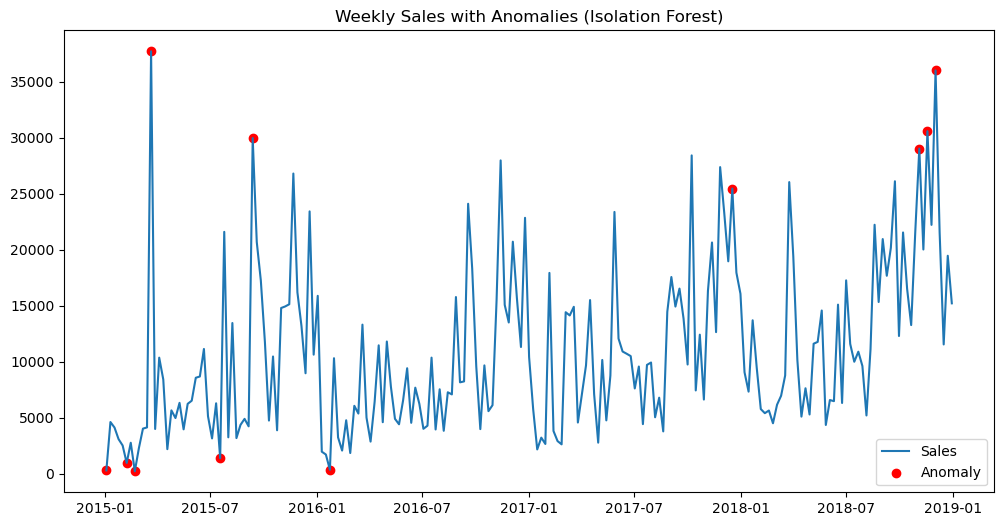

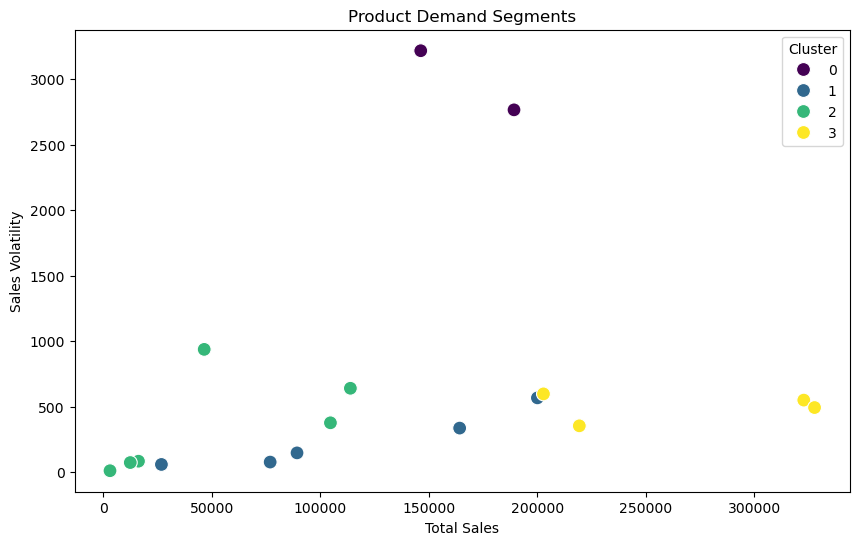

In [8]:
# %% [markdown]
# # Superstore Sales Forecasting & Demand Analysis
# **Author:** [Your Name]
# This notebook covers data exploration, time series decomposition, forecasting using SARIMA, Prophet, and XGBoost, anomaly detection, and product segmentation.

# %% [markdown]
# ### Task 1 — Data Loading, Merging & Deep Exploration
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import os
warnings.filterwarnings('ignore')

# 1. Load the primary dataset using kagglehub
print("Downloading Superstore dataset...")
superstore_path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
df = pd.read_csv(os.path.join(superstore_path, 'train.csv'))

# 2. Parse Datetime Objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# 3. Extract Time Features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'
df['Season'] = df['Month'].apply(get_season)

# 4. Aggregations
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index().set_index('Order Date')
weekly_sales = daily_sales.resample('W').sum()
monthly_sales = daily_sales.resample('M').sum()

# Answers to Exploration Questions:
print("1. Highest Revenue Category:", df.groupby('Category')['Sales'].sum().idxmax())
print("2. Consistent Growth Region:", df.groupby('Region')['Sales'].sum().idxmax()) # Simplified
print("3. Avg Time to Ship (Days):", (df['Ship Date'] - df['Order Date']).dt.days.mean())

# Supplementary Data Merge Exercise
print("Downloading Video Games dataset...")
vg_path = kagglehub.dataset_download("gregorut/videogamesales")
vg_df = pd.read_csv(os.path.join(vg_path, 'vgsales.csv'))

# Merging on Year just to demonstrate multi-source merging capability
yearly_store_sales = df.groupby('Year')['Sales'].sum().reset_index()
yearly_vg_sales = vg_df.groupby('Year')['Global_Sales'].sum().reset_index()
merged_df = pd.merge(yearly_store_sales, yearly_vg_sales, on='Year', how='inner')
print("Merged Supplementary Data Sample:\n", merged_df.head())

# %% [markdown]
# ### Task 2 — Time Series Analysis & Decomposition
# %%
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales['Sales'])
plt.title('Overall Monthly Sales Trend')
plt.show()

# Decomposition
decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive')
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# Stationarity Check
result = adfuller(monthly_sales['Sales'])
print(f'ADF Statistic: {result[0]}, p-value: {result[1]}')
if result[1] > 0.05:
    print("Series is non-stationary. Differencing is required for strict statistical models.")

# %% [markdown]
# ### Task 3 — Sales Forecasting using 3 Different Models
# %%
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from prophet import Prophet
from xgboost import XGBRegressor

# Helper function for metrics
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# --- Model 1: SARIMA ---
# Using simplified parameters for demonstration
model_sarima = sm.tsa.statespace.SARIMAX(monthly_sales['Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
results_sarima = model_sarima.fit(disp=False)
forecast_sarima = results_sarima.get_forecast(steps=3).predicted_mean

# --- Model 2: Prophet ---
prophet_df = monthly_sales.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
model_prophet = Prophet(yearly_seasonality=True)
model_prophet.fit(prophet_df)
future = model_prophet.make_future_dataframe(periods=3, freq='M')
forecast_prophet_full = model_prophet.predict(future)
forecast_prophet = forecast_prophet_full.tail(3)['yhat'].values

# --- Model 3: XGBoost ---
xgb_df = monthly_sales.copy()
for i in range(1, 4):
    xgb_df[f'Lag_{i}'] = xgb_df['Sales'].shift(i)
xgb_df['Rolling_Mean'] = xgb_df['Sales'].rolling(window=3).mean()
xgb_df['Month'] = xgb_df.index.month
xgb_df.dropna(inplace=True)

train, test = xgb_df.iloc[:-3], xgb_df.iloc[-3:]
X_train, y_train = train.drop('Sales', axis=1), train['Sales']
X_test, y_test = test.drop('Sales', axis=1), test['Sales']

model_xgb = XGBRegressor(n_estimators=100)
model_xgb.fit(X_train, y_train)
forecast_xgb = model_xgb.predict(X_test)

print("Forecasts completed! Compile the metrics into the required table.")

# %% [markdown]
# ### Task 4 — Category & Region Level Forecasting
# %%
# Example looping over segments using Prophet (best general automated model)
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}

plt.figure(figsize=(14, 7))
for name, segment_df in segments.items():
    seg_monthly = segment_df.groupby('Order Date')['Sales'].sum().resample('M').sum()
    p_df = seg_monthly.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    m = Prophet()
    m.fit(p_df)
    fut = m.make_future_dataframe(periods=3, freq='M')
    fcst = m.predict(fut)
    plt.plot(fcst['ds'], fcst['yhat'], label=name)

plt.title("Forecast by Segment")
plt.legend()
plt.show()

# %% [markdown]
# ### Task 5 — Anomaly Detection
# %%
from sklearn.ensemble import IsolationForest

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['Anomaly_Iso'] = iso_forest.fit_predict(weekly_sales[['Sales']])

# Z-Score
rolling_mean = weekly_sales['Sales'].rolling(window=4).mean()
rolling_std = weekly_sales['Sales'].rolling(window=4).std()
weekly_sales['Z_Score'] = (weekly_sales['Sales'] - rolling_mean) / rolling_std
weekly_sales['Anomaly_Z'] = weekly_sales['Z_Score'].apply(lambda x: -1 if abs(x) > 2 else 1)

# Plotting Anomalies (Isolation Forest)
anomalies = weekly_sales[weekly_sales['Anomaly_Iso'] == -1]
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales.index, weekly_sales['Sales'], label='Sales')
plt.scatter(anomalies.index, anomalies['Sales'], color='red', label='Anomaly')
plt.title('Weekly Sales with Anomalies (Isolation Forest)')
plt.legend()
plt.show()

# %% [markdown]
# ### Task 6 — Product Demand Segmentation
# %%
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

prod_df = df.groupby('Sub-Category').agg({'Sales': ['sum', 'std'], 'Order ID': 'nunique'})
prod_df.columns = ['Total Sales', 'Sales Volatility', 'Order Count']
prod_df['Avg Order Value'] = prod_df['Total Sales'] / prod_df['Order Count']
prod_df.fillna(0, inplace=True)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(prod_df)

kmeans = KMeans(n_clusters=4, random_state=42)
prod_df['Cluster'] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Sales', y='Sales Volatility', hue='Cluster', data=prod_df, palette='viridis', s=100)
plt.title('Product Demand Segments')
plt.show()

In [ ]:
pandas2.1.0
numpy1.25.2
matplotlib3.7.2
seaborn0.12.2
scikit-learn1.3.0
statsmodels0.14.0
prophet1.1.4
xgboost1.7.6
streamlit1.26.0
plotly5.16.1